In [16]:
#Basic Setup
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
#cols = ["mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/comparisons/group1/"  #path directory for saving pngs :)
#matched=baseline

#matched = matched[(matched["nphe_htcc"]!=-9999)&(matched["nphe_htcc"]!=0)]
#print("ftof_path_1A:  ", matched["nphe_htcc"].describe())
#print("\nQuick eyeball:")
#print(f"  ftof_time_1A range: [{matched['nphe_htcc'].min():.2f}, {matched['nphe_htcc'].max():.2f}]")

In [17]:
ranges=[
[-2212, 2212], #pid
[-2212, 2212],    #mc_matching_pid
[0.5, 5],    #p
[4, 44], #theta
[0, 1],  #beta  
[-10, 10], #chi2pid
[0,1], #rich_RQ
[0,1.4], #Vz
[0, 6], #sector
[0,360]  #Phi  
]    

parts = [321, 211, 2212]
colors= ["Green", "Blue", "Red"]
labels=["K+", "Pi+", "P"]
    

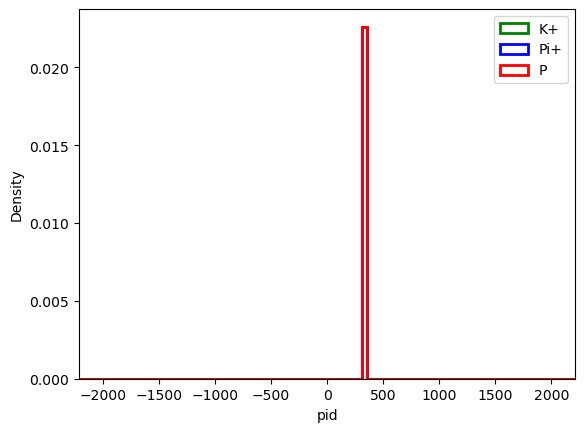

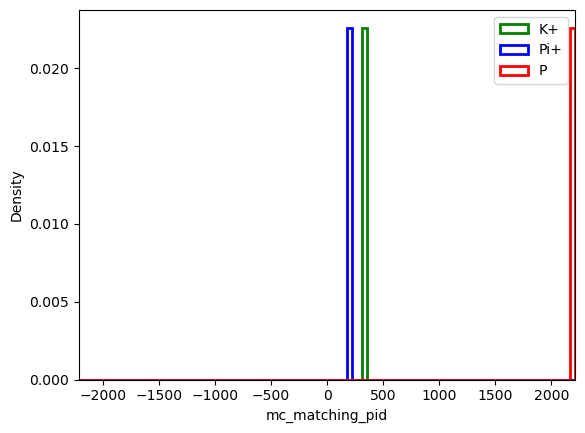

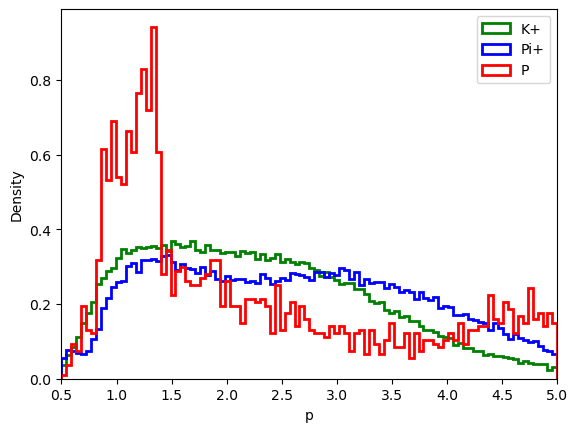

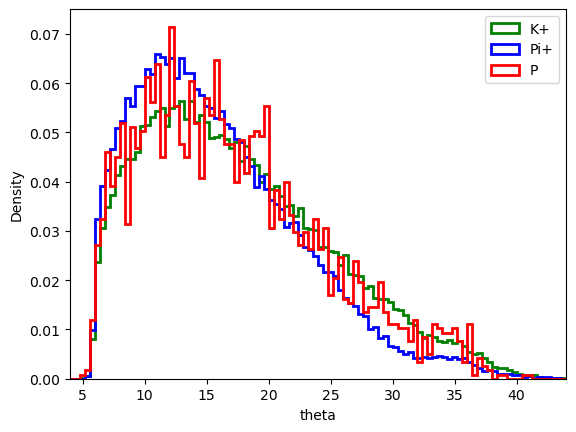

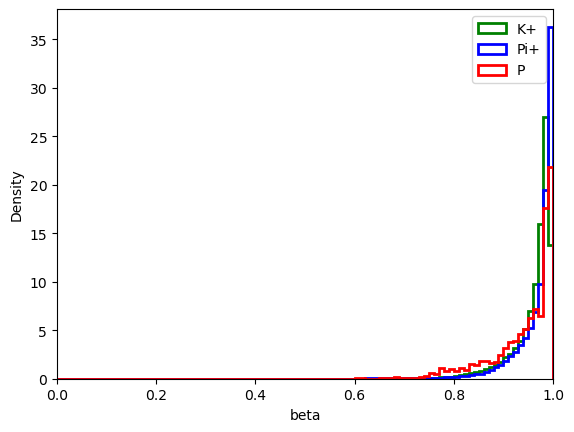

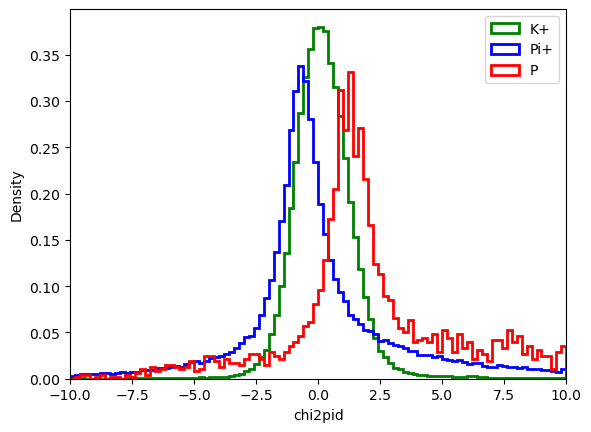

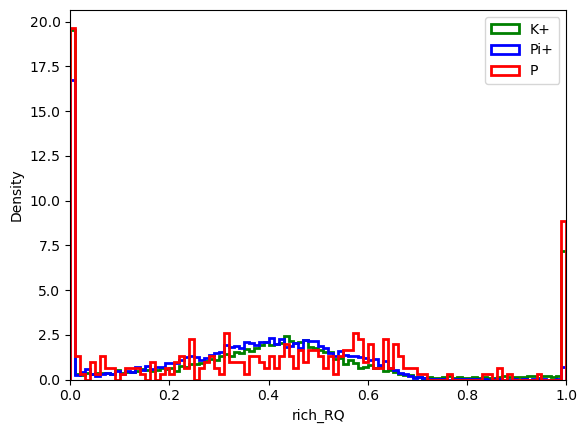

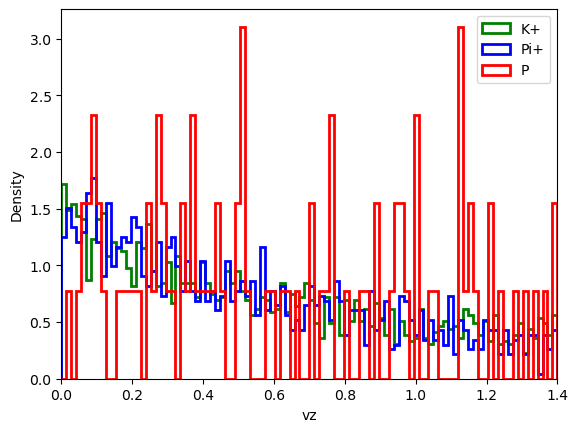

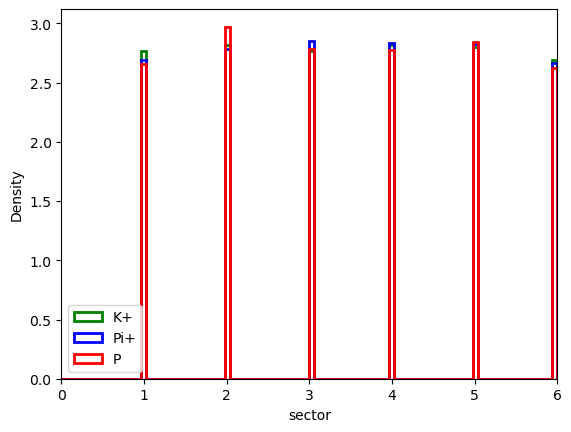

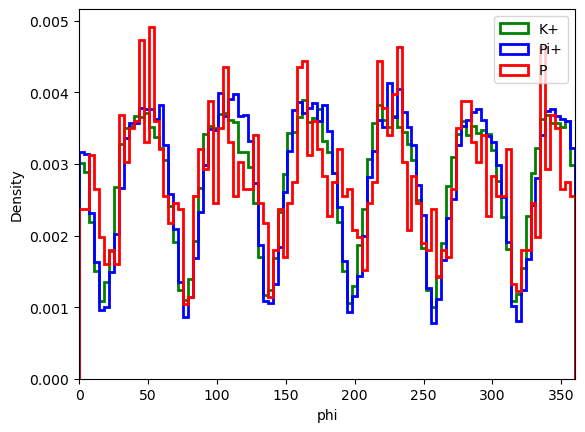

In [18]:
cnt=0
subset = matched[matched["pid"]==321]
for varb in cols:
    #beta
    dfs=[]
    for i in range(3):
        id=parts[i]
        pidCut = subset[subset["mc_matching_pid"]==id]
        dfs.append(pidCut)

    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
        ax.hist(
            df[varb],
            bins=100,
            range=(ranges[cnt][0], ranges[cnt][1]),
            histtype='step',
            color=colors[i],
            density=True,
            linewidth=2,
            label=labels[i]
        )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varb)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varb+"CompareEBK.png", dpi=150)
    cnt=cnt+1
    plt.show()

In [24]:
#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
cols = ["pid","mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()

In [25]:
ranges=[
[-2212,2212], #pid
[-2212, 2212],    #mc_matching_pid
[0, 25],    #ftof_energy_1A
[0, 25], #ftof_energy_1B
[100, 200],  # ftof_time_1A
[100, 200], #ftof_time_1B
[600,800], #ftof_path_1A
[600,800], #ftof_path_1B
[0, 1], #ecin_energy
[0,1],  #ecout_energy
[100,200], #ecin_time 
[100,200], #ecout_time 
[733,800], #ecin_path
[733,800], #ecout_path
[1,16] #nphe_htcc    
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/comparisons/group2/"  #path directory for saving pngs :)

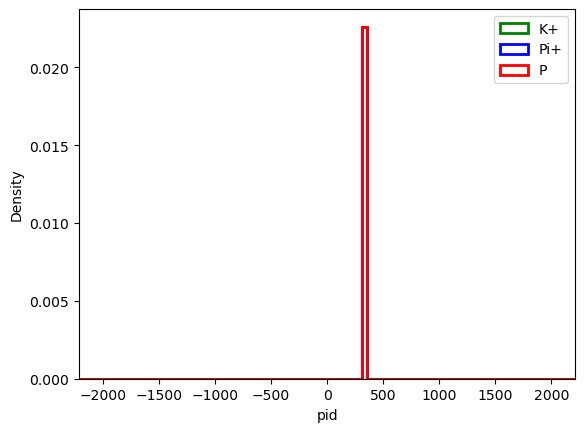

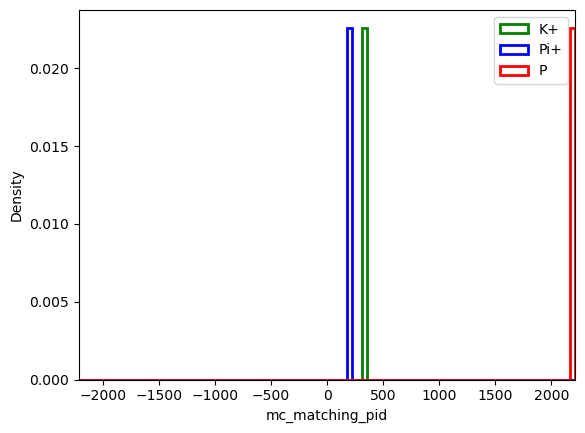

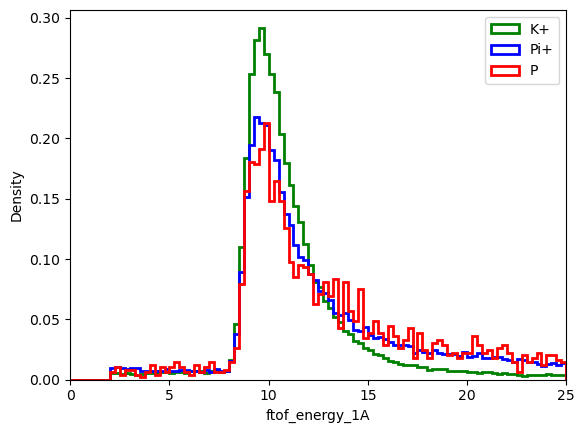

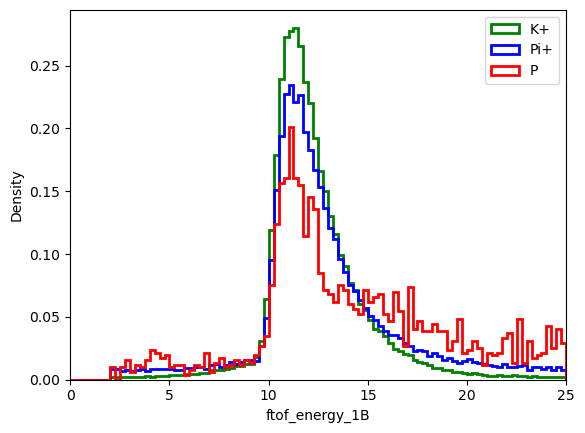

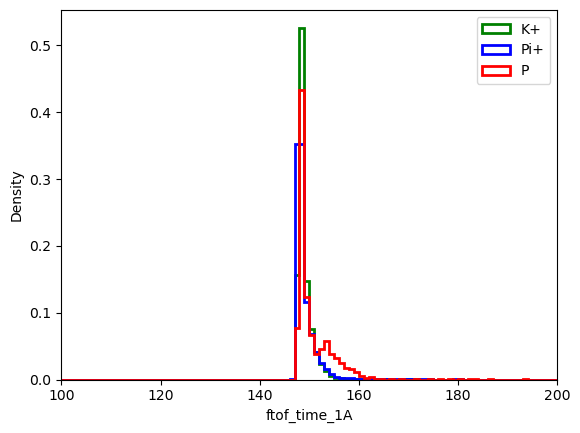

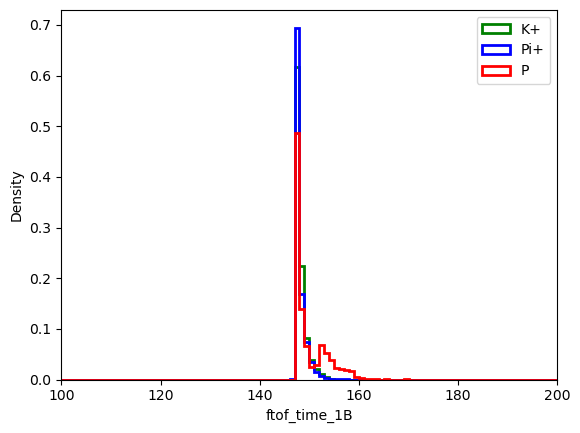

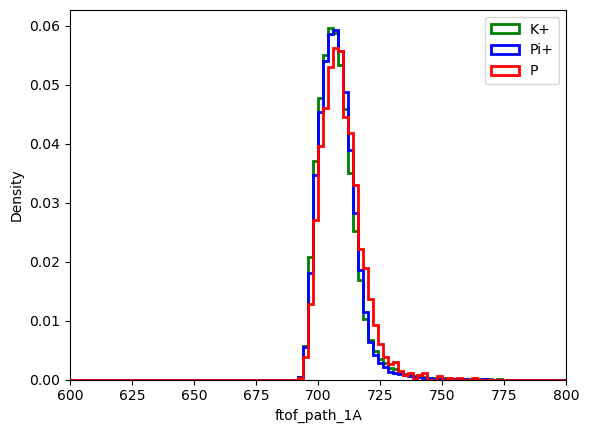

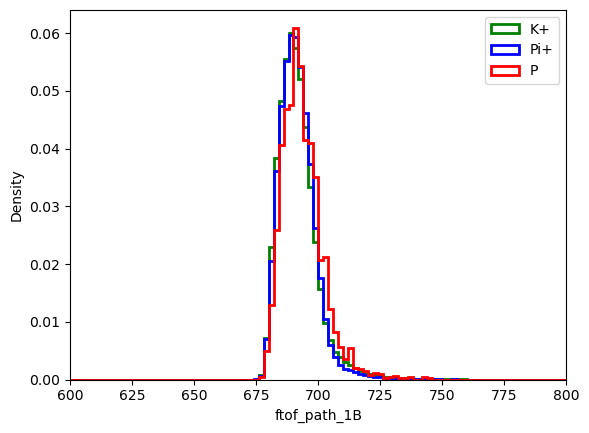

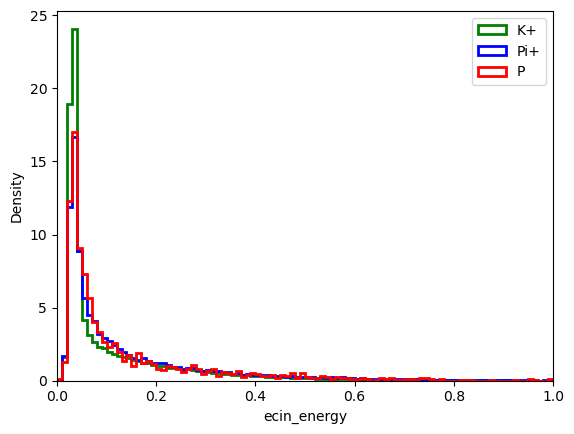

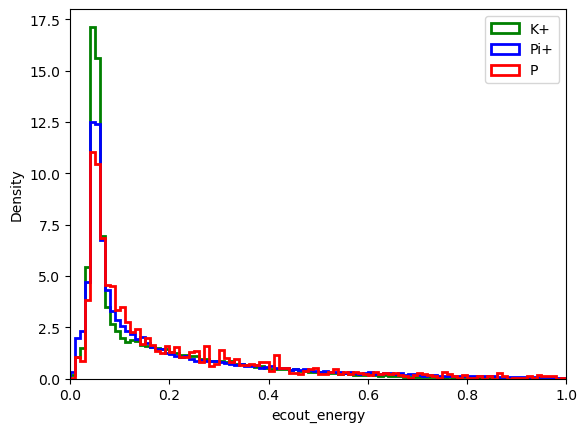

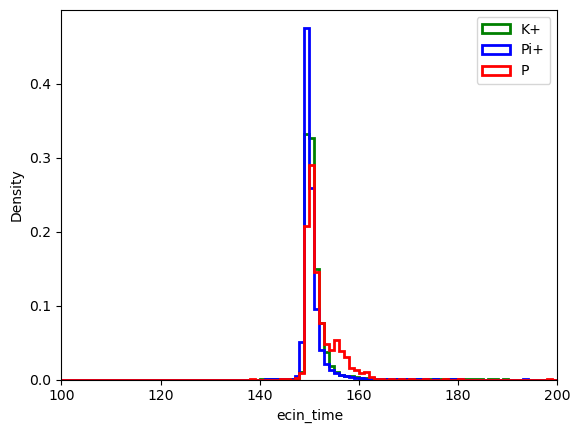

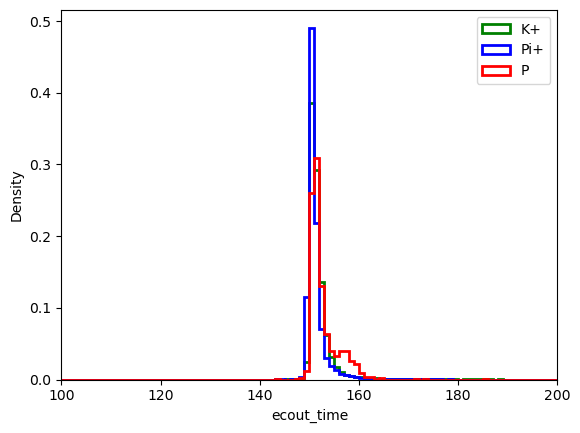

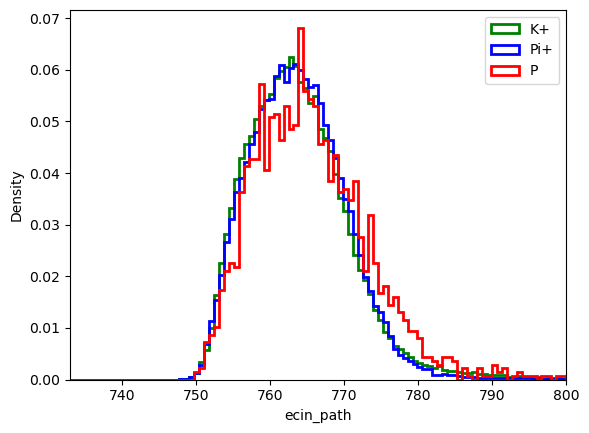

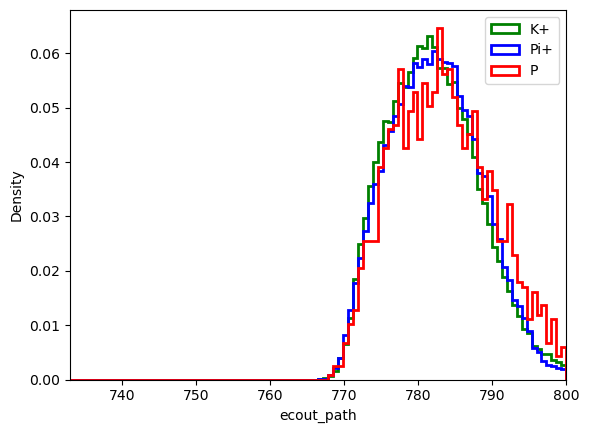

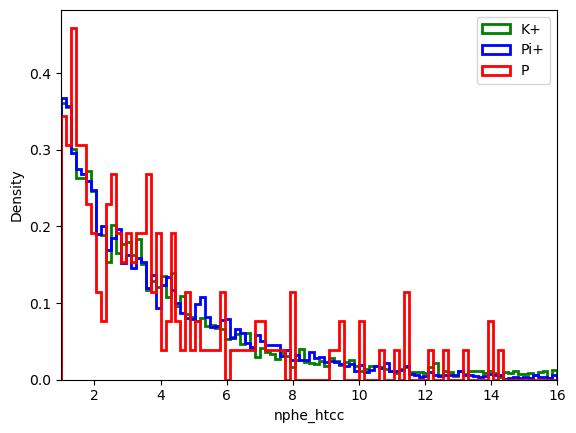

In [26]:
cnt=0
subset = matched[matched["pid"]==321]
for varb in cols:
    #beta
    dfs=[]
    for i in range(3):
        id=parts[i]
        pidCut = subset[subset["mc_matching_pid"]==id]
        dfs.append(pidCut)

    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
        ax.hist(
            df[varb],
            bins=100,
            range=(ranges[cnt][0], ranges[cnt][1]),
            histtype='step',
            color=colors[i],
            density=True,
            linewidth=2,
            label=labels[i]
        )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varb)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varb+"CompareEBK.png", dpi=150)
    cnt=cnt+1
    plt.show()

In [27]:
#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
#cols = ["pid","mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]
cols =["pid","mc_matching_pid","pcal_energy","pcal_time","pcal_path", "ftof_energy_2", "ftof_time_2", "ftof_path_2"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()

In [28]:
ranges=[
[-2212, 2212], #pid
[-2212, 2212],    #mc_matching_pid
[0, 0.9],    #pcal_energy
[100, 200], #pcal_time
[700, 800],  # pcal_path
[0, 16], #ftof_energy_2
[133,200], #ftof_time_2
[600,800] #ftof_path_2
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/comparisons/group3/"  #path directory for saving pngs :)

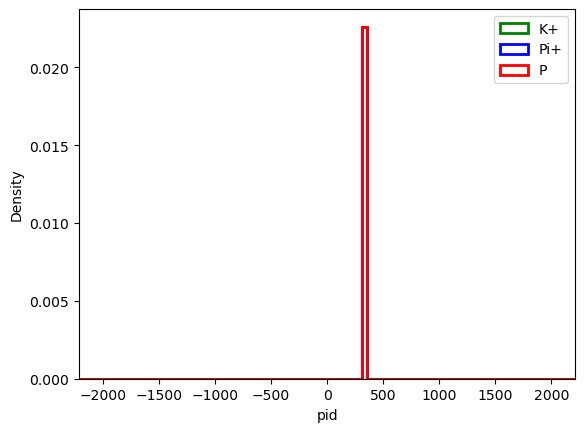

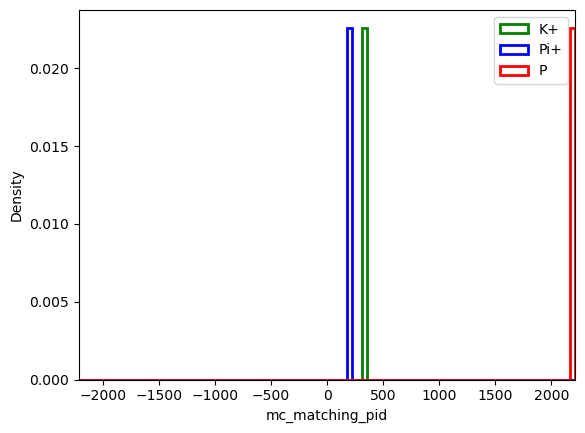

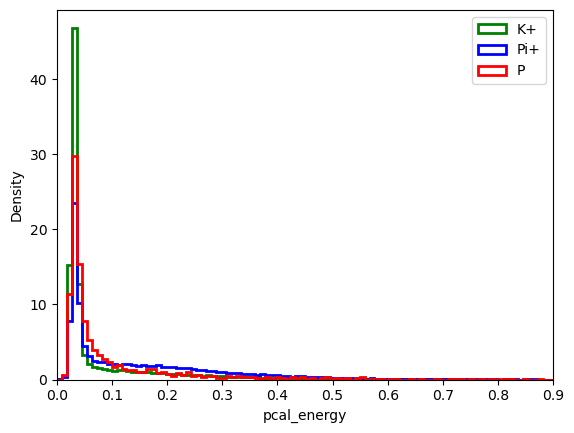

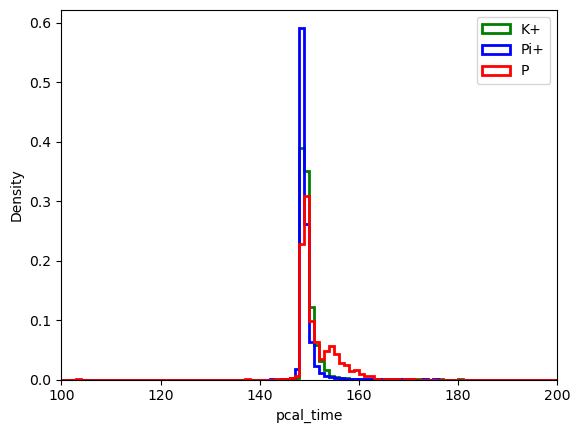

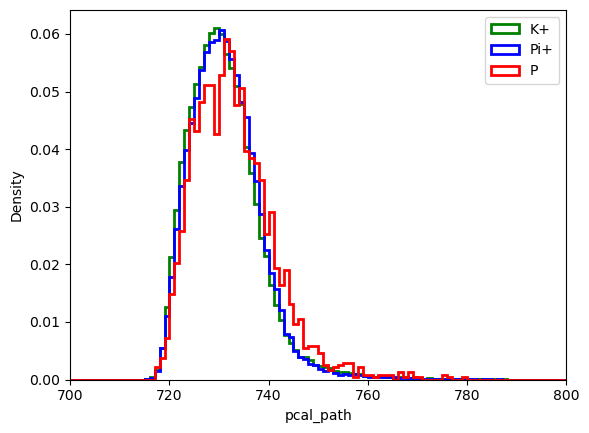

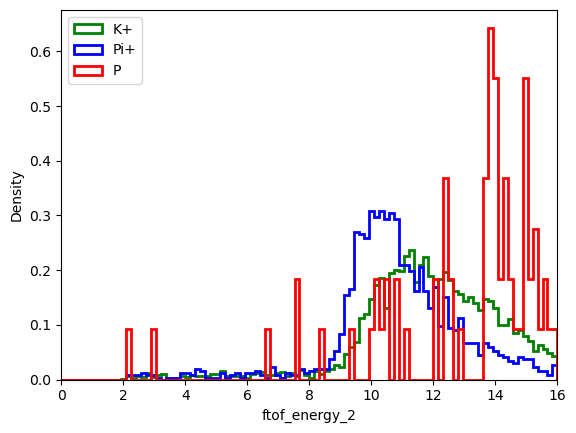

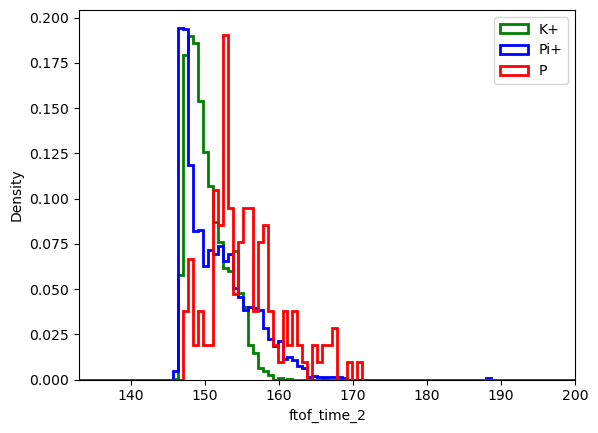

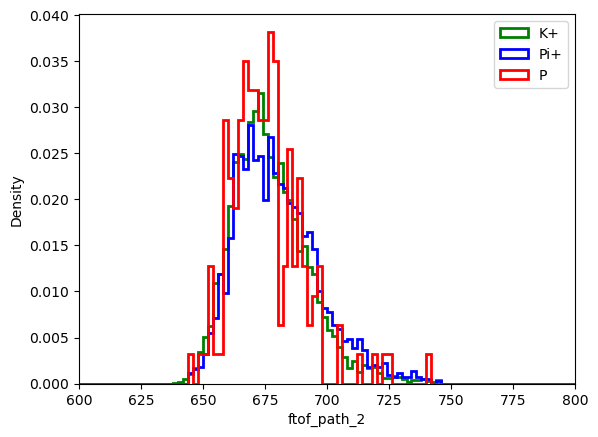

In [29]:
cnt=0
subset = matched[matched["pid"]==321]
for varb in cols:
    #beta
    dfs=[]
    for i in range(3):
        id=parts[i]
        pidCut = subset[subset["mc_matching_pid"]==id]
        dfs.append(pidCut)

    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
        ax.hist(
            df[varb],
            bins=100,
            range=(ranges[cnt][0], ranges[cnt][1]),
            histtype='step',
            color=colors[i],
            density=True,
            linewidth=2,
            label=labels[i]
        )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varb)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varb+"CompareEBK.png", dpi=150)
    cnt=cnt+1
    plt.show()